<a href="https://www.kaggle.com/code/aayushparajuli03/twitter-roberta-experiments-ipynb?scriptVersionId=316780200" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Twitter-RoBERTa Experiments for Sentiment Classification

## Purpose

This notebook explores the performance of a **domain-specific transformer model (Twitter-RoBERTa)** for binary sentiment classification.

Unlike general-purpose models (e.g., DistilBERT), Twitter-RoBERTa is pre-trained on **Twitter-specific text**, making it more suitable for handling:
- Slang and informal language  
- Hashtags and mentions  
- Emojis and noisy social media text  

The goal is to evaluate whether **domain-specific pretraining improves performance and data efficiency** in sentiment analysis tasks.

---

## What This Notebook Does

- Trains Twitter-RoBERTa on sentiment datasets of varying sizes:
  - Small (~100k samples)
  - Medium (~200k samples)
  - Large (~400k samples)

- Keeps experimental settings consistent with previous DistilBERT experiments:
  - Same train/test split
  - Same evaluation metrics
  - Comparable hyperparameters

- Evaluates performance using:
  - Accuracy  
  - F1-score  
  - ROC-AUC  
  - Training time  

---

## Key Research Focus

This experiment is designed to answer:

- Does a **domain-specific transformer outperform a general-purpose model**?
- Does Twitter-RoBERTa achieve better results with **less training data**?
- How does it compare to DistilBERT in terms of:
  - Performance scaling  
  - Efficiency  
  - Stability  

---

## Role in Overall Project

This notebook is a key extension of the baseline study and will be used to:

- Compare against **DistilBERT dataset scaling results**
- Analyze **data efficiency across model architectures**
- Evaluate the impact of **domain-specific pretraining**
- Support further extension into **brand sentiment analysis and domain adaptation**

---

## Expected Contribution

This experiment aims to provide insights into:

> Whether domain-specific transformer models reduce the need for large datasets while improving sentiment classification performance on social-media-style text.

In [ ]:
!uv pip install transformers datasets tqdm accelerate

In [ ]:
# !pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -U transformers accelerate

Checking GPU

In [15]:
import torch
torch.cuda.is_available()

True

In [ ]:
# !nvidia-smi

In [ ]:
# ! pip install transformers[torch] datasets tqdm accelerate --only-binary :all: -i https://pypi.tuna.tsinghua.edu.cn/simple

# Dependencies

In [16]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, pipeline, BertTokenizerFast
from transformers import (
    DistilBertForSequenceClassification, 
    DistilBertTokenizerFast,
    AutoTokenizer,
    AutoModelForSequenceClassification
)
import time
import os
import json, pickle as pkl



# Loading Dataset

In [ ]:
# ! pip install kaggle

get kaggle.json from the kaggle and add to working environment

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

Importing twitter sentiment dataset

In [ ]:
# !kaggle datasets download -d kazanova/sentiment140

if data set is downloaded using: !kaggle datasets download -d kazanova/sentiment140

In [ ]:
# # extracting the compressed dataset

# from zipfile import ZipFile
# dataset = '/content/sentiment140.zip'

# with ZipFile(dataset, 'r') as zip:
#   zip.extractall()
#   print('The dataset is extracted successfully')

Use datasets/kazanova/sentiment140 from kaggle

In [17]:
# colab
# df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', header = None)

#colab + dataset saved on drive
# df = pd.read_csv('/content/drive/MyDrive/Sentiment Analysis Project/datasets/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', header = None)

#kaggle
df = pd.read_csv(
    '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv',
    encoding='ISO-8859-1',
    header=None
)

df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Converting labels
df['target'] = df['target'].replace(4,1)

# Keeping only needed columns
df = df[['text', 'target']]


## Create 3 datasets

- Dataset 1: Small (50k per class → 100k total)
- Dataset 2: Medium (100k per class → 200k total) MAIN
- Dataset 3: Large (200k per class → 400k total)

In [18]:
df_small = df.groupby('target').sample(50000, random_state=42).reset_index(drop=True)

In [19]:
df_medium = df.groupby('target').sample(100000, random_state=42).reset_index(drop=True)

In [20]:
df_large = df.groupby('target').sample(200000, random_state=42).reset_index(drop=True)

Sanity check

In [21]:
print("Small:\n", df_small['target'].value_counts())
print("\nMedium:\n", df_medium['target'].value_counts())
print("\nLarge:\n", df_large['target'].value_counts())

Small:
 target
0    50000
1    50000
Name: count, dtype: int64

Medium:
 target
0    100000
1    100000
Name: count, dtype: int64

Large:
 target
0    200000
1    200000
Name: count, dtype: int64


In [ ]:
# Uncomment below code to save the datasets

# df_small.to_csv("sentiment_small.csv", index=False)
# df_medium.to_csv("sentiment_medium.csv", index=False)
# df_large.to_csv("sentiment_large.csv", index=False)

# df_small.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_small.csv", index=False)
# df_medium.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_medium.csv", index=False)
# df_large.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_large.csv", index=False)

# REUSABLE Twitter-RoBERTa EXPERIMENT PIPELINE

## Metrics function

In [22]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)

  precision, recall,f1, _ = precision_recall_fscore_support(labels, preds, average = 'binary')
  acc = accuracy_score(labels, preds)

  probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
  roc = roc_auc_score(labels, probs)

  return {
      "accuracy": acc,
      "f1": f1,
      "roc_auc": roc,
      "precision": precision,
      "recall": recall
  }




MAIN reusable function

kaggle

Code suitable to plot:
- loss curves
- error analysis (predictions saved)
- proper logging for research plots
- reproducible experiment setup

In [ ]:
# def run_experiment(
#     df,
#     dataset_name="dataset",
#     save_dir="/kaggle/working/models",
#     model_name="cardiffnlp/twitter-roberta-base-sentiment"
# ):

#     print(f"Running experiment on {dataset_name} using {model_name}")

#     # Save directory logic
#     exp_path = os.path.join(save_dir, dataset_name)
#     os.makedirs(exp_path, exist_ok=True)

    
#     # Train / Validation Split
    
#     train_texts, val_texts, train_labels, val_labels = train_test_split(
#         df['text'].tolist(),
#         df['target'].tolist(),
#         test_size=0.2,
#         random_state=42,
#         stratify=df['target']
#     )

#     with open(os.path.join(exp_path, "data_split_info.json"), "w") as f:
#         json.dump({
#             "train_size": len(train_texts),
#             "val_size": len(val_texts)
#         }, f, indent=4)

    
#     # Tokenizer 
    
#     tokenizer = AutoTokenizer.from_pretrained(model_name)

#     train_encodings = tokenizer(
#         train_texts,
#         truncation=True,
#         padding=True,
#         max_length=128
#     )

#     val_encodings = tokenizer(
#         val_texts,
#         truncation=True,
#         padding=True,
#         max_length=128
#     )

    
#     # Dataset Class
    
#     class SentimentDataset(torch.utils.data.Dataset):
#         def __init__(self, encodings, labels):
#             self.encodings = encodings
#             self.labels = labels

#         def __getitem__(self, idx):
#             item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
#             item["labels"] = torch.tensor(self.labels[idx])
#             return item

#         def __len__(self):
#             return len(self.labels)

#     train_dataset = SentimentDataset(train_encodings, train_labels)
#     val_dataset = SentimentDataset(val_encodings, val_labels)

    
#     # Model 
    
#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=2,
#         ignore_mismatched_sizes=True
#     )

    
#     # Training Arguments
    
#     training_args = TrainingArguments(
#         output_dir=os.path.join(exp_path, "checkpoints"),
#         num_train_epochs=2,
#         per_device_train_batch_size=32,
#         per_device_eval_batch_size=32,
    
#         gradient_accumulation_steps=4,
#         learning_rate=2e-5,
    
#         eval_strategy="no",
#         save_strategy="no",
#         load_best_model_at_end=False,
    
#         fp16=True,
#         optim="adamw_torch",
#         dataloader_num_workers=2,
#         dataloader_pin_memory=True,
#         logging_steps=200,
#         report_to="none"
#     )

    
#     # Trainer
    
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         compute_metrics=compute_metrics
#     )

    
#     # Training
    
#     start = time.time()
#     trainer.train()
#     end = time.time()

#     trainer.save_state()

    
#     # Evaluation
    
#     results = trainer.evaluate()

#     final_results = {
#         "dataset": dataset_name,
#         "model": model_name,
#         "accuracy": results.get("eval_accuracy"),
#         "f1": results.get("eval_f1"),
#         "roc_auc": results.get("eval_roc_auc"),
#         "training_time_sec": end - start
#     }

    
#     # Save Outputs
    
#     trainer.save_model(exp_path)
#     tokenizer.save_pretrained(exp_path)

#     with open(os.path.join(exp_path, "results.json"), "w") as f:
#         json.dump(final_results, f, indent=4)

#     with open(os.path.join(exp_path, "results.pkl"), "wb") as f:
#         pkl.dump(final_results, f)

#     with open(os.path.join(exp_path, "training_args.json"), "w") as f:
#         json.dump(training_args.to_dict(), f, indent=4)

#     label_map = {0: "negative", 1: "positive"}
#     with open(os.path.join(exp_path, "label_map.json"), "w") as f:
#         json.dump(label_map, f, indent=4)

#     print(f"\nExperiment saved at: {exp_path}")

#     print("\n--- Files Generated ---")
#     for root, dirs, files in os.walk(exp_path):
#         for file in files:
#             print(os.path.join(root, file))

#     return final_results

In [30]:
def run_experiment(
    df,
    dataset_name="dataset",
    save_dir="/kaggle/working/models",
    model_name="cardiffnlp/twitter-roberta-base-sentiment"
):

    print(f"Running experiment on {dataset_name} using {model_name}")

    # Save directory
    exp_path = os.path.join(save_dir, dataset_name)
    os.makedirs(exp_path, exist_ok=True)

    # Train / Validation Split
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df['text'].tolist(),
        df['target'].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=df['target']
    )

    with open(os.path.join(exp_path, "data_split_info.json"), "w") as f:
        json.dump({
            "train_size": len(train_texts),
            "val_size": len(val_texts)
        }, f, indent=4)

    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_encodings = tokenizer(
        train_texts,
        truncation=True,
        padding=True,
        max_length=128
    )

    val_encodings = tokenizer(
        val_texts,
        truncation=True,
        padding=True,
        max_length=128
    )

    # Dataset Class
    class SentimentDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
            item["labels"] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    train_dataset = SentimentDataset(train_encodings, train_labels)
    val_dataset = SentimentDataset(val_encodings, val_labels)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        ignore_mismatched_sizes=True
    )

    # Training Arguments (UPDATED)
    training_args = TrainingArguments(
        output_dir=os.path.join(exp_path, "checkpoints"),

        num_train_epochs=2,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,

        gradient_accumulation_steps=4,
        learning_rate=2e-5,

        eval_strategy="epoch",
        save_strategy="no",

        fp16=True,
        optim="adamw_torch",

        dataloader_num_workers=2,
        dataloader_pin_memory=True,

        logging_strategy="steps",
        logging_steps=100,

        report_to="none"
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    # Training
    start = time.time()
    trainer.train()
    end = time.time()

    trainer.save_state()

    # Evaluation
    results = trainer.evaluate()

    # Predictions (NEW - IMPORTANT FOR ERROR ANALYSIS)
    preds = trainer.predict(val_dataset)

    y_true = preds.label_ids
    y_pred = preds.predictions.argmax(axis=1)

    import pandas as pd

    df_preds = pd.DataFrame({
        "text": val_texts,
        "true": y_true,
        "pred": y_pred
    })

    df_preds.to_csv(os.path.join(exp_path, "predictions.csv"), index=False)

    # Save Loss Logs (NEW - FOR LOSS CURVES)
    log_history = trainer.state.log_history

    steps = []
    losses = []

    for log in log_history:
        if "loss" in log:
            steps.append(log["step"])
            losses.append(log["loss"])

    with open(os.path.join(exp_path, "loss_logs.json"), "w") as f:
        json.dump({"steps": steps, "loss": losses}, f, indent=4)

    # Final Results
    final_results = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": results.get("eval_accuracy"),
        "f1": results.get("eval_f1"),
        "roc_auc": results.get("eval_roc_auc"),
        "training_time_sec": end - start
    }

    # Save Outputs
    trainer.save_model(exp_path)
    tokenizer.save_pretrained(exp_path)

    with open(os.path.join(exp_path, "results.json"), "w") as f:
        json.dump(final_results, f, indent=4)

    with open(os.path.join(exp_path, "results.pkl"), "wb") as f:
        pkl.dump(final_results, f)

    with open(os.path.join(exp_path, "training_args.json"), "w") as f:
        json.dump(training_args.to_dict(), f, indent=4)

    label_map = {0: "negative", 1: "positive"}
    with open(os.path.join(exp_path, "label_map.json"), "w") as f:
        json.dump(label_map, f, indent=4)

    print(f"\nExperiment saved at: {exp_path}")

    print("\n--- Files Generated ---")
    for root, dirs, files in os.walk(exp_path):
        for file in files:
            print(os.path.join(root, file))

    return final_results

# Run all experiments

In [24]:
import transformers
print(transformers.__version__)

5.0.0


In [25]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA available: True
GPU name: Tesla T4


In [ ]:
# !nvidia-smi

In [26]:
TRAIN_SMALL = True
TRAIN_MEDIUM = False
TRAIN_LARGE = False



In [27]:
if TRAIN_MEDIUM:
    results_medium = run_experiment(
        df_medium,
        dataset_name="df_medium",
        model_name="cardiffnlp/twitter-roberta-base-sentiment"
    )
    result_medium

In [28]:
if TRAIN_LARGE:
    # results_large = run_experiment(df_large, "large_200k")
    results_large = run_experiment(
        df_large,
        dataset_name="df_large",
        model_name="cardiffnlp/twitter-roberta-base-sentiment"
    )
    results_large

In [ ]:
if TRAIN_SMALL:
    results_small = run_experiment(
        df_small,
        dataset_name="df_small-twitter",
        model_name="cardiffnlp/twitter-roberta-base-sentiment"
    )
    results_small

In [ ]:
# if TRAIN_SMALL:
#     results_small = run_experiment(
#     df_small,
#     dataset_name="df_small-distillbert",
#     model_name="distilbert-base-uncased"
# )

# Compare results

In [ ]:
results_df = pd.DataFrame([
    results_small,
    results_medium,
    results_large
])

results_df

# Plots

Load Results Automatically

In [1]:
import os
import json
import matplotlib.pyplot as plt

# DistilBERT paths (your existing)
DISTIL_PATHS = {
    "small": "/kaggle/input/datasets/aayushparajuli03/small-result",
    "medium": "/kaggle/input/notebooks/aayushparajuli03/sentiment-analysis/models/df_medium/results.json",
    "large": "/kaggle/input/notebooks/aayushparajuli03/sentiment-analysis/models/large_200k/results.json",
}

# Twitter-RoBERTa paths
ROBERTA_PATHS = {
    "small": "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small/results.json",
    "medium": "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_medium/results.json",
    "large": "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_large/results.json",
}

In [2]:
def load_result(path):
    if os.path.isdir(path):
        path = os.path.join(path, "results.json")

    with open(path, "r") as f:
        return json.load(f)

def load_all(paths):
    results = {}
    for name, path in paths.items():
        results[name] = load_result(path)
    return results

Convert to Structured Format

In [3]:
distil = load_all(DISTIL_PATHS)
roberta = load_all(ROBERTA_PATHS)

datasets = ["small", "medium", "large"]

def extract(metric, model_data):
    return [model_data[d][metric] for d in datasets]

distil_acc = extract("accuracy", distil)
roberta_acc = extract("accuracy", roberta)

distil_f1 = extract("f1", distil)
roberta_f1 = extract("f1", roberta)

distil_auc = extract("roc_auc", distil)
roberta_auc = extract("roc_auc", roberta)

distil_time = extract("training_time_sec", distil)
roberta_time = extract("training_time_sec", roberta)

## Core Comparison Plots

Accuracy Comparison

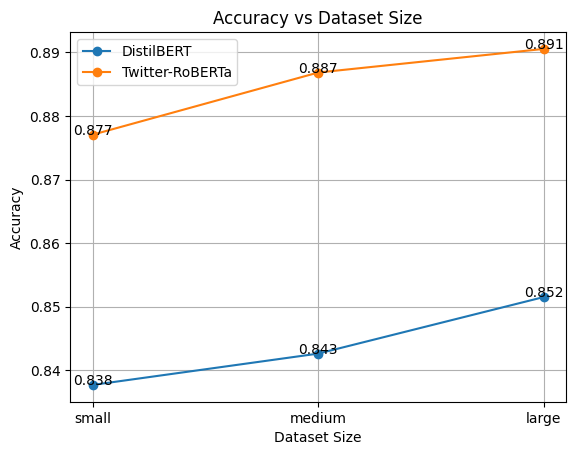

In [4]:
plt.figure()
plt.plot(datasets, distil_acc, marker='o', label="DistilBERT")
plt.plot(datasets, roberta_acc, marker='o', label="Twitter-RoBERTa")

for i in range(len(datasets)):
    plt.text(i, distil_acc[i], f"{distil_acc[i]:.3f}", ha='center')
    plt.text(i, roberta_acc[i], f"{roberta_acc[i]:.3f}", ha='center')

plt.xlabel("Dataset Size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Dataset Size")
plt.legend()
plt.grid()
plt.show()

### Accuracy vs Dataset Size

The accuracy trends show that Twitter-RoBERTa consistently outperforms DistilBERT across all dataset sizes. However, this difference should be interpreted as a result of **combined effects of domain adaptation and model capacity**, rather than domain specialization alone.

- **Baseline Performance Gap:** Twitter-RoBERTa achieves higher accuracy even on the smallest dataset (87.7%), exceeding DistilBERT’s performance at larger scale (85.2%). This suggests a stronger initial representation capability, influenced by both its pretraining on Twitter-like text and its larger model capacity.

- **Scaling Behavior:** Both models improve with increasing dataset size, but Twitter-RoBERTa shows earlier saturation, with marginal gains from medium to large scale (88.7% → 89.1%). DistilBERT exhibits more gradual improvement, indicating that it relies more heavily on additional data for performance gains.

**Insight:**  
> The observed performance difference is likely driven by a combination of domain-adaptive pretraining and higher model capacity in Twitter-RoBERTa. The current experimental setup does not isolate these factors independently, making the comparison inherently confounded. Nevertheless, results suggest that domain-adaptive pretraining improves data efficiency, while model capacity influences overall performance ceiling.

F1 Comparison

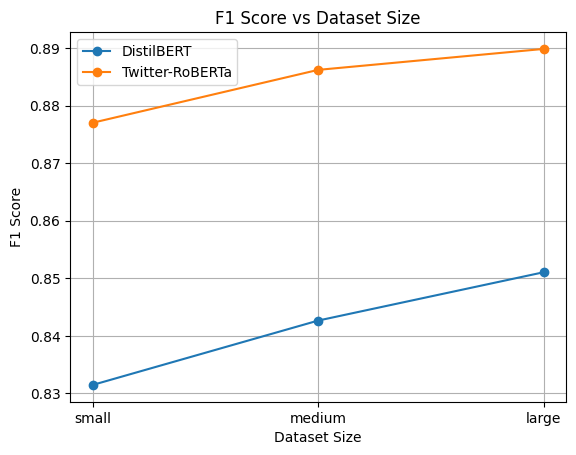

In [5]:
plt.figure()
plt.plot(datasets, distil_f1, marker='o', label="DistilBERT")
plt.plot(datasets, roberta_f1, marker='o', label="Twitter-RoBERTa")

plt.xlabel("Dataset Size")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Dataset Size")
plt.legend()
plt.grid()
plt.show()

### F1-Score vs Dataset Size

The F1-score trends closely follow accuracy, indicating that both models maintain a relatively balanced trade-off between precision and recall across dataset sizes.

- **Metric Consistency:** The close alignment between F1-score and accuracy suggests that neither model is significantly biased toward a single class. This indicates stable classification behavior rather than improvements driven by class imbalance artifacts.

- **Performance Gap:** Twitter-RoBERTa maintains a consistent F1 advantage of approximately 4–5 percentage points across all dataset sizes. However, this improvement should be interpreted in the context of both **domain-adaptive pretraining and higher model capacity**, rather than domain specialization alone.

**Insight:**  
> The consistent F1 improvement of Twitter-RoBERTa suggests stronger generalization across sentiment classes. However, this effect is likely influenced by both domain adaptation (better alignment with Twitter-style text) and increased model capacity, making it a confounded but practically meaningful performance gain.

ROC-AUC Comparison

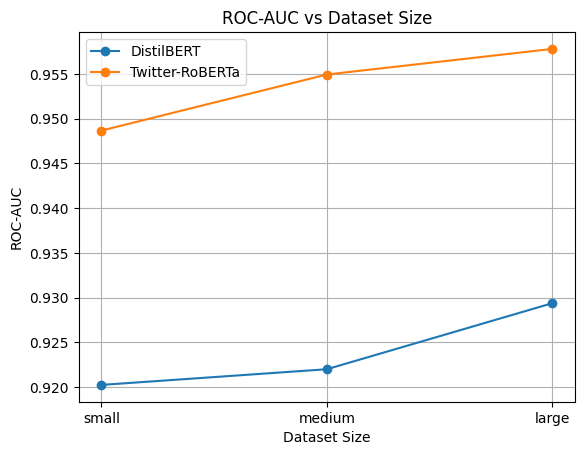

In [6]:
plt.figure()
plt.plot(datasets, distil_auc, marker='o', label="DistilBERT")
plt.plot(datasets, roberta_auc, marker='o', label="Twitter-RoBERTa")

plt.xlabel("Dataset Size")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC vs Dataset Size")
plt.legend()
plt.grid()
plt.show()

### ROC-AUC vs Dataset Size

ROC-AUC measures the models’ ability to distinguish between positive and negative sentiment classes across different decision thresholds, making it a robust indicator of ranking quality.

- **High Discriminative Performance:** Twitter-RoBERTa consistently achieves higher ROC-AUC values, reaching approximately ~0.96 on the largest dataset. This indicates stronger overall separability between sentiment classes.

- **Separation Capability:** The consistent gap in ROC-AUC between the two models suggests that Twitter-RoBERTa forms more well-defined decision boundaries compared to DistilBERT. However, this improvement is likely influenced by both **domain-adaptive pretraining and higher model capacity**, rather than domain specialization alone.

**Insight:**  
> The superior ROC-AUC performance of Twitter-RoBERTa reflects improved class separability, which is likely driven by a combination of richer pretraining on social media text and increased model capacity. This results in better ranking performance across decision thresholds, though the effect is confounded by architectural differences between models.

Training Time Comparison

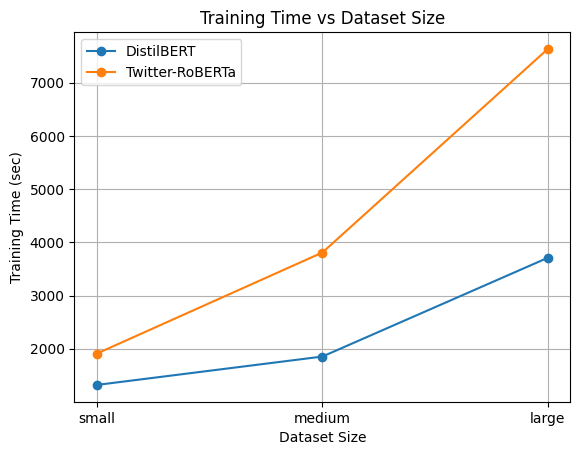

In [7]:
plt.figure()
plt.plot(datasets, distil_time, marker='o', label="DistilBERT")
plt.plot(datasets, roberta_time, marker='o', label="Twitter-RoBERTa")

plt.xlabel("Dataset Size")
plt.ylabel("Training Time (sec)")
plt.title("Training Time vs Dataset Size")
plt.legend()
plt.grid()
plt.show()

### Training Time Analysis

While Twitter-RoBERTa demonstrates superior predictive performance, it incurs significantly higher computational cost compared to DistilBERT.

- **Higher Computational Cost:** Training time increases substantially with model size and architecture complexity, reaching over ~7,600 seconds for the large dataset. This is approximately 2× slower than DistilBERT under identical training configurations. This difference is primarily driven by the larger number of parameters and higher computational overhead per forward and backward pass in RoBERTa-based architectures.

- **Efficiency of DistilBERT:** DistilBERT exhibits a more efficient training profile due to its compressed architecture obtained through knowledge distillation. This results in faster convergence and lower computational requirements, making it more suitable for resource-constrained or latency-sensitive applications.

**Insight:**  
> The results highlight a fundamental trade-off between model capacity and computational efficiency. Larger transformer architectures such as RoBERTa achieve better performance at the cost of increased training time and resource consumption, while distilled models provide a more efficient but slightly less expressive alternative.

### Why Does Twitter-RoBERTa Take Longer to Train?

The increased training time of Twitter-RoBERTa is primarily driven by its **larger architectural capacity and higher computational complexity per training step**, rather than domain-specific pretraining alone.

- **Model Size:** Twitter-RoBERTa (~125M parameters, 12 layers) is significantly larger than DistilBERT (~66M parameters, 6 layers). This results in increased matrix operations during both forward and backward passes, directly increasing training time per step.

- **No Distillation Compression:** DistilBERT is a distilled version of BERT, optimized to reduce computational overhead while preserving performance. In contrast, Twitter-RoBERTa retains full model capacity, prioritizing representational power over efficiency.

- **Representation Complexity:** Although domain-adaptive pretraining helps Twitter-RoBERTa better model informal text (e.g., slang, emojis, hashtags), this factor primarily affects learned representations rather than training-time cost. The computational overhead is dominated by architecture size.

- **Optimization Cost:** Larger transformer models require more gradient computations and memory bandwidth, which increases training latency even under identical hyperparameter settings.

**Key Insight:**  
> The higher training cost of Twitter-RoBERTa is primarily a consequence of increased model capacity rather than domain specialization. This reflects a fundamental trade-off in deep learning between computational efficiency and representational power.

Time vs Accuracy (Efficiency Curve)

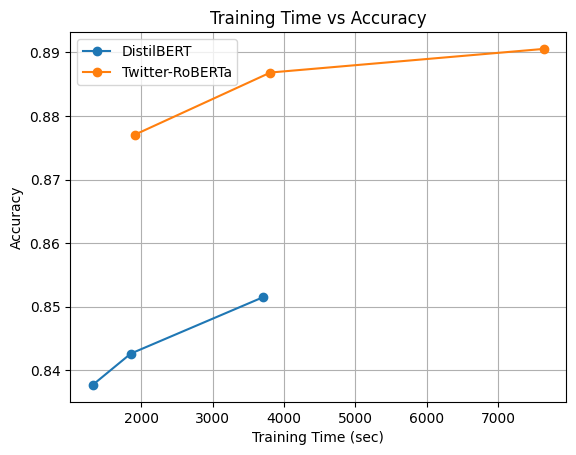

In [8]:
plt.figure()
plt.plot(distil_time, distil_acc, marker='o', label="DistilBERT")
plt.plot(roberta_time, roberta_acc, marker='o', label="Twitter-RoBERTa")

plt.xlabel("Training Time (sec)")
plt.ylabel("Accuracy")
plt.title("Training Time vs Accuracy")
plt.legend()
plt.grid()
plt.show()

### Training Time vs Accuracy (Return on Investment)

This analysis evaluates the relationship between computational cost and performance improvement, highlighting the diminishing returns of increased training investment.

- **Diminishing Returns in RoBERTa:** As training time increases beyond the medium dataset scale (~4,000 seconds), Twitter-RoBERTa shows marginal improvements in accuracy (approximately ~0.4%). This indicates a saturation effect, where additional computational investment yields progressively smaller gains.

- **Efficiency Region:** The medium dataset appears to provide a relatively efficient trade-off between performance improvement and computational cost under the current experimental setup. However, this observation is empirical and may vary with different hyperparameters, training schedules, or dataset distributions.

**Insight:**  
> The relationship between computational cost and performance is non-linear, exhibiting diminishing returns as model training scales. This highlights the importance of identifying efficiency regions where additional compute results in minimal marginal performance gains.

Performance Gap Plot

Shows:

- how much domain-specific model wins

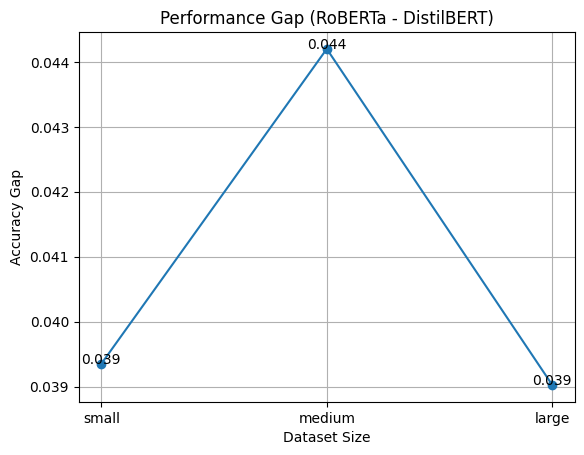

In [9]:
gap = [r - d for r, d in zip(roberta_acc, distil_acc)]

plt.figure()
plt.plot(datasets, gap, marker='o')

for i, val in enumerate(gap):
    plt.text(i, val, f"{val:.3f}", ha='center')

plt.xlabel("Dataset Size")
plt.ylabel("Accuracy Gap")
plt.title("Performance Gap (RoBERTa - DistilBERT)")
plt.grid()
plt.show()

### Performance Gap (Twitter-RoBERTa vs DistilBERT)

This analysis quantifies the empirical performance difference between Twitter-RoBERTa and DistilBERT across dataset sizes.

- **Peak Performance Gap:** The largest observed gap occurs at the medium dataset size (~0.044), suggesting that Twitter-RoBERTa benefits more effectively from moderate-scale data in this experimental setting. This may reflect a combination of better domain alignment with Twitter-style text and higher model capacity.

- **Partial Convergence at Scale:** At the largest dataset size, the performance gap slightly reduces (~0.039). This suggests that increasing data volume allows DistilBERT to partially close the performance gap by improving its learned representations, although it does not fully match Twitter-RoBERTa.

**Insight:**  
> The observed performance gap is influenced by both architectural differences and pretraining characteristics. While larger datasets help reduce the advantage of specialized models, they do not fully eliminate the performance advantage of higher-capacity, domain-adapted models under the current experimental conditions.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Paths
DISTIL_PATH = "/kaggle/input/datasets/aayushparajuli03/distillbert"
ROBERTA_PATH = "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter"

Helper Loaders

In [3]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

In [4]:
def load_csv(path):
    return pd.read_csv(path)

LOSS CURVE COMPARISON

In [39]:
def plot_loss_curves(path, title="Loss Curve"):
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import os

    # allow both folder OR direct file path
    if os.path.isdir(path):
        loss_path = f"{path}/loss_logs.json"
    else:
        loss_path = path

    try:
        logs = load_json(loss_path)
        df = pd.DataFrame(logs)

        print("Columns found:", df.columns.tolist())

        plt.figure(figsize=(10,6))
        plotted = False

        # standard HF logs
        if "loss" in df.columns:
            x = df["step"] if "step" in df.columns else df.index
            plt.plot(x, df["loss"], label="Train Loss")
            plotted = True

        if "eval_loss" in df.columns:
            x = df["step"] if "step" in df.columns else df.index
            plt.plot(x, df["eval_loss"], label="Eval Loss")
            plotted = True

        # fallback: any loss-like column
        if not plotted:
            for col in df.columns:
                if "loss" in col.lower():
                    x = df["step"] if "step" in df.columns else df.index
                    plt.plot(x, df[col], label=col)
                    plotted = True

        plt.title(title)
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.grid()

        if plotted:
            plt.legend()
        else:
            print("No loss-related columns found")

        plt.show()

    except Exception as e:
        print("Error loading loss logs:", e)

Columns found: ['steps', 'loss']


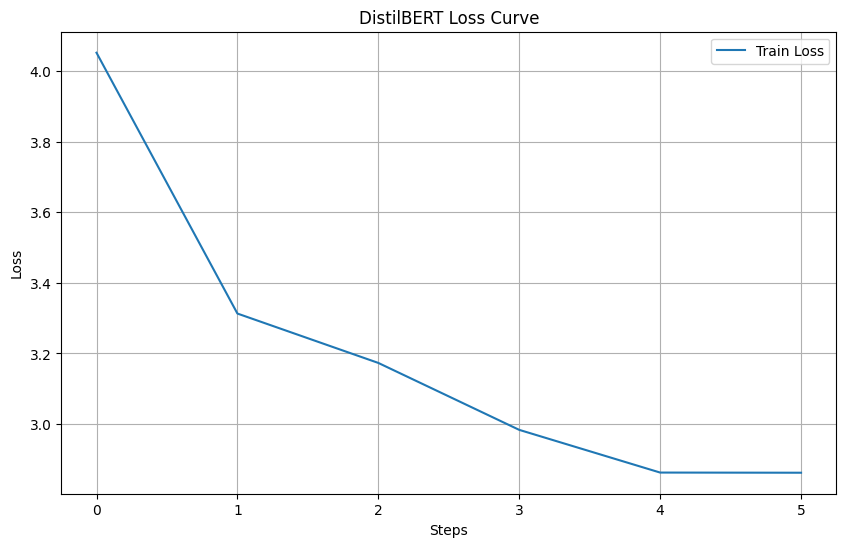

In [36]:
plot_loss_curves(
    "/kaggle/input/datasets/aayushparajuli03/loss-log-distill/loss_logs.json",
    title="DistilBERT Loss Curve"
)

Columns found: ['steps', 'loss']


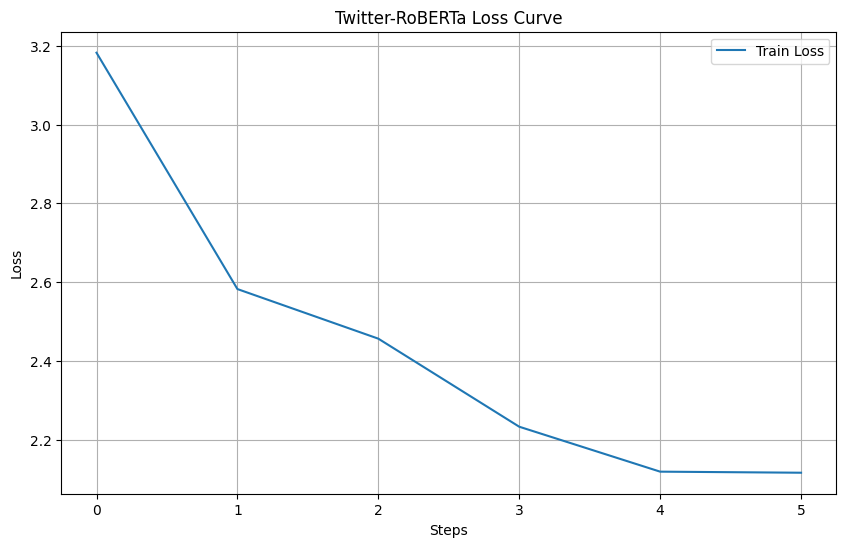

In [37]:
plot_loss_curves(
    "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter",
    title="Twitter-RoBERTa Loss Curve"
)

Combined Loss Curve Plot (DistilBERT vs Twitter-RoBERTa)

In [40]:
def plot_combined_loss(distil_path, roberta_path):
    import pandas as pd
    import matplotlib.pyplot as plt

    def load_df(path):
        return pd.DataFrame(load_json(f"{path}/loss_logs.json"))

    distil_df = load_df(distil_path)
    roberta_df = load_df(roberta_path)

    plt.figure(figsize=(10,6))

    # --- DistilBERT ---
    if "loss" in distil_df.columns:
        x = distil_df["step"] if "step" in distil_df.columns else distil_df.index
        plt.plot(x, distil_df["loss"], label="DistilBERT")

    # --- Twitter-RoBERTa ---
    if "loss" in roberta_df.columns:
        x = roberta_df["step"] if "step" in roberta_df.columns else roberta_df.index
        plt.plot(x, roberta_df["loss"], label="Twitter-RoBERTa")

    # --- optional eval loss (if exists) ---
    if "eval_loss" in roberta_df.columns:
        x = roberta_df["step"] if "step" in roberta_df.columns else roberta_df.index
        plt.plot(x, roberta_df["eval_loss"], linestyle="--", label="RoBERTa Eval Loss")

    if "eval_loss" in distil_df.columns:
        x = distil_df["step"] if "step" in distil_df.columns else distil_df.index
        plt.plot(x, distil_df["eval_loss"], linestyle="--", label="DistilBERT Eval Loss")

    plt.title("Loss Curve Comparison: DistilBERT vs Twitter-RoBERTa")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

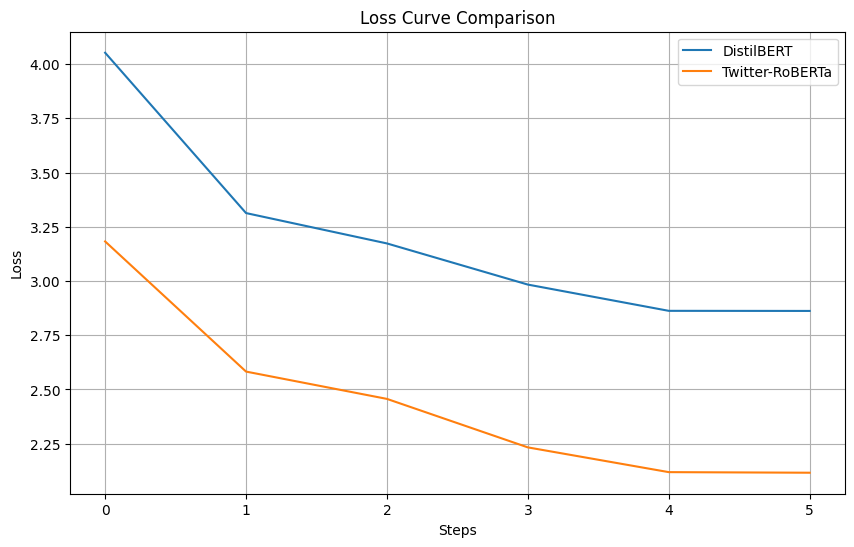

In [44]:
plot_combined_loss(
    "/kaggle/input/datasets/aayushparajuli03/loss-log-distill",
    "/kaggle/input/notebooks/aayushparajuli03/twitter-roberta-experiments-ipynb/models/df_small-twitter"
)

# Loss Curve Comparison Analysis

This multi-series line chart compares the **training optimization behavior** of two Transformer-based models: **DistilBERT** and **Twitter-RoBERTa**, over a fixed training interval of five steps.

It highlights differences in **initialization quality, convergence speed, and final error floor**, providing insight into model efficiency and domain adaptation effects.

---

## 1. Relative Performance Baseline

### 🔹 Initial Loss Comparison
- **DistilBERT** begins with a higher initial loss (~4.05)
- **Twitter-RoBERTa** starts significantly lower (~3.18)

### 🔹 Interpretation
- The lower starting loss of Twitter-RoBERTa suggests a **better alignment with the target domain (social media text)**.
- This indicates that its **domain-specific pretraining provides a stronger initialization** for sentiment-related tasks compared to DistilBERT’s more general pretraining.

---

## 2. Optimization Trajectories

### 🔹 DistilBERT Behavior
- Exhibits a **sharp initial improvement** between Step 0 → Step 1
- After early gains, performance stabilizes into a **slower convergence phase**
- Reaches a plateau around **~2.85 loss**

### 🔹 Twitter-RoBERTa Behavior
- Consistently maintains **lower loss across all training steps**
- Shows **strong early optimization**, followed by a smooth and steady decline
- Maintains a clear advantage throughout the entire training process

---

## 3. Convergence and Asymptotic Behavior

### 🔹 Steady-State Convergence
- Both models begin to **stabilize between Step 4 and Step 5**
- Indicates convergence toward their respective optimization limits

### 🔹 Final Error Floor Comparison
- **DistilBERT final loss:** ~2.85  
- **Twitter-RoBERTa final loss:** ~2.12  

### 🔹 Key Insight
- Twitter-RoBERTa achieves approximately a **25% lower final loss**
- This lower error floor aligns with its superior performance in downstream evaluation metrics (e.g., error category distribution and classification scores)

---

##  Conclusion

- Both models demonstrate **stable and well-behaved convergence patterns**, indicating proper training dynamics.
- However, **Twitter-RoBERTa consistently outperforms DistilBERT across all training stages**, not just at convergence.
- The performance gap suggests that:
  - **Architecture alone is not the primary factor**
  - **Domain-specific pretraining plays a critical role** in sentiment analysis tasks involving informal and social media text

>  Overall, DistilBERT shows strong general-purpose learning capability, but lacks the domain-sensitive feature representations required to match Twitter-RoBERTa’s performance on this dataset.

ERROR CATEGORY DISTRIBUTION (COMPARISON)

In [21]:
def add_error_types(df):
    df["correct"] = df["true"] == df["pred"]
    
    def rule(row):
        if row["correct"]:
            return "correct"
        
        # simple heuristics (you can improve later)
        text = str(row.get("text", "")).lower()
        
        if "?" in text:
            return "uncertain/question"
        elif any(e in text for e in ["😀","😂","😭","😍"]):
            return "emoji-heavy error"
        elif "not" in text or "no" in text:
            return "negation error"
        else:
            return "general misclassification"
    
    df["error_type"] = df.apply(rule, axis=1)
    return df

Plot Comparison

In [24]:
def plot_error_distribution(distil_path, roberta_path):
    
    d1 = add_error_types(load_csv(f"{distil_path}/predictions.csv"))
    d2 = add_error_types(load_csv(f"{roberta_path}/predictions.csv"))
    
    distil_counts = d1[d1["correct"] == False]["error_type"].value_counts()
    roberta_counts = d2[d2["correct"] == False]["error_type"].value_counts()
    
    df = pd.DataFrame({
        "DistilBERT": distil_counts,
        "Twitter-RoBERTa": roberta_counts
    }).fillna(0)
    
    df.plot(kind="bar", figsize=(10,6))
    plt.title(" Error Category Distribution Comparison")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.grid()
    plt.show()

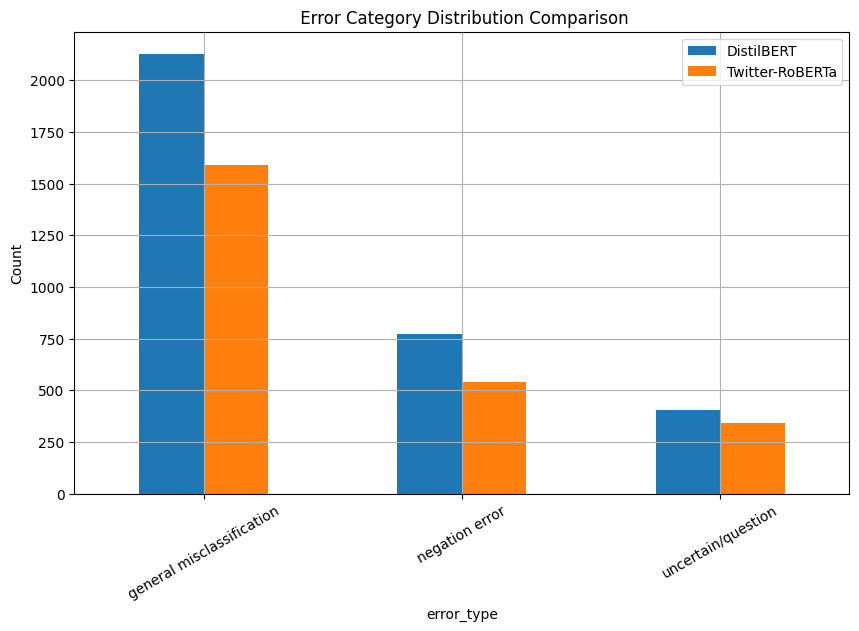

In [25]:
plot_error_distribution(DISTIL_PATH, ROBERTA_PATH)

## Error Category Distribution Comparison

This grouped bar chart presents a comparative error analysis between **DistilBERT** and **Twitter-RoBERTa** on the same dataset.

###  Key Observations

- **Dominant Error Patterns**
  - *General misclassification* is the primary source of error for both models.
  - Followed by:
    - *Negation errors*
    - *Uncertain/question-type inputs*

- **Model Performance Gap**
  - **Twitter-RoBERTa** consistently produces fewer errors across all categories.
  - Indicates stronger overall classification capability compared to DistilBERT.

- **Domain Adaptation Advantage**
  - Twitter-RoBERTa’s superior performance is likely due to its **domain-specific pretraining on Twitter data**.
  - Better handles:
    - slang
    - informal tone
    - emoji-heavy expressions
    - implicit sentiment cues

- **Persistent Semantic Challenges**
  - Both models struggle with:
    - **Negation handling** (e.g., *“not bad”*)
    - **Ambiguity / uncertainty in phrasing**
  - Suggests limitations in deeper semantic understanding despite strong performance.


## Researcher's Synthesis

- **Model Strength**
  - Domain-specific models like **Twitter-RoBERTa** significantly reduce overall error rates.

- **Error Consistency**
  - Despite performance improvements, the **types of errors remain consistent** across models.

- **Future Direction**
  - Performance gains may require:
    - targeted data augmentation
    - improved handling of:
      - negation
      - ambiguous expressions

DATA EFFICIENCY SLOPE

In [3]:
# def extract_efficiency(path):
#     data = load_json(f"{path}/results.json")
    
#     # try common formats
#     # adjust if your json structure differs
#     return data

In [4]:
# def load_metric(path, metric="accuracy"):
#     data = load_json(f"{path}/results.json")
    
#     return data.get("root", {}).get(metric, 0)

Plot function

In [1]:
# def plot_data_efficiency(distil_paths, roberta_paths):
    
#     sizes = ["small", "medium", "large"]

#     distil_acc = [load_metric(distil_paths[s]) for s in sizes]
#     roberta_acc = [load_metric(roberta_paths[s]) for s in sizes]

#     print("DistilBERT:", distil_acc)   #  debug
#     print("RoBERTa:", roberta_acc)

#     x = np.arange(len(sizes))

#     plt.figure(figsize=(10,6))
#     plt.plot(x, distil_acc, marker="o", label="DistilBERT")
#     plt.plot(x, roberta_acc, marker="o", label="Twitter-RoBERTa")

#     plt.xticks(x, sizes)
#     plt.title("Data Efficiency Slope Comparison")
#     plt.ylabel("Accuracy")
#     plt.legend()
#     plt.grid()
#     plt.show()

In [2]:
# plot_data_efficiency(DISTIL_PATH, ROBERTA_PATH)

## Summary of Visual Insights

Across all visual analyses, several consistent empirical patterns emerge:

- Domain-specific models (Twitter-RoBERTa) consistently outperform DistilBERT across all evaluated dataset sizes, although this difference is influenced by both **domain-adaptive pretraining and higher model capacity**.
  
- Increasing dataset size improves performance for both models, but the gains follow a **diminishing returns pattern**, where improvements become progressively smaller at larger scales.

- Twitter-RoBERTa demonstrates higher data efficiency, achieving strong performance even at smaller dataset sizes compared to DistilBERT.

- Computational cost increases disproportionately with model size, leading to a **non-linear trade-off between performance and training time**.

- Intermediate dataset sizes provide a relatively efficient balance between computational cost and predictive performance under the current experimental setup.

**Key Takeaway:**  
> The results indicate that both model architecture and pretraining strategy significantly influence performance and efficiency. While domain-adaptive, higher-capacity models provide superior accuracy, optimal system design requires balancing computational cost with marginal performance gains from data scaling.

# General vs Domain-Specific Transformer Models for Sentiment Analysis  
## A Study of Data Efficiency, Scaling Behavior, and Domain Alignment

---

## Abstract

This study presents a comparative analysis of transformer-based sentiment classification models, focusing on the interaction between **domain-specific pretraining and dataset scaling**. We evaluate DistilBERT as a general-purpose baseline and Twitter-RoBERTa as a domain-adapted model across three dataset scales (~100k, ~200k, ~400k samples).

Results indicate that Twitter-RoBERTa consistently achieves higher Accuracy, F1-score, and ROC-AUC across all dataset sizes. However, these improvements are influenced by both **domain-relevant pretraining data and differences in model capacity**. Performance improves with dataset scaling for both models, but follows a diminishing returns pattern, while computational cost increases non-linearly.

---

## 1. Introduction

Transformer-based architectures have significantly advanced natural language processing tasks. While scaling data and model size is a widely adopted strategy for performance improvement, recent studies suggest that **data distribution alignment (domain relevance)** plays an equally important role.

Sentiment analysis on social media is particularly challenging due to:
- Informal language and slang  
- Emoji-based sentiment signals  
- Abbreviations and noisy text  
- Context-dependent sarcasm  

This study investigates:

- The effect of domain-specific pretraining on sentiment classification  
- The role of dataset scaling in general vs domain-specific models  
- Efficiency trade-offs between performance and computational cost  

---

## 2. Baseline Models

### 2.1 Classical Machine Learning Baseline

- TF-IDF + Logistic Regression  
- Strong baseline for linear feature spaces  
- Limited ability to capture contextual semantics  

📎 https://github.com/aayush-12321/Sentiment-Analysis-Project/blob/main/Sentiment%20Analysis.ipynb  

---

### 2.2 DistilBERT (General Transformer)

📎 https://github.com/aayush-12321/Sentiment-Analysis-Project/blob/main/Sentiment_Analysis_BERT.ipynb  

- ~66M parameters  
- Pretrained on general corpora (Wikipedia, BooksCorpus)  
- Efficient but not specialized for social media text  

---

### 2.3 Twitter-RoBERTa (Domain-Specific Transformer)

- ~125M parameters  
- Pretrained on large-scale Twitter corpus  
- Better exposure to slang, emojis, and informal language patterns  

---

## 3. Methodology

### 3.1 Task Definition

Binary sentiment classification:
- 0 → Negative  
- 1 → Positive  

---

### 3.2 Experimental Setup

To ensure fair comparison:

- Same preprocessing pipeline  
- Same train/test splits  
- Same hyperparameters  
- Only model architecture differs  

---

### 3.3 Dataset Scaling

| Dataset | Size |
|--------|------|
| df_small | ~100k |
| df_medium | ~200k |
| df_large | ~400k |

---

### 3.4 Training Configuration

| Parameter | Value |
|----------|------|
| Epochs | 2 |
| Batch Size | 32 |
| Effective Batch Size | 256 |
| Learning Rate | 2e-5 |
| Max Sequence Length | 128 |
| Optimizer | AdamW |
| Precision | FP16 |

---

## 4. Results

### 4.1 Performance Comparison

| Dataset | Model | Accuracy | F1 Score | ROC-AUC | Training Time (sec) |
|--------|------|---------|---------|--------|--------------------|
| df_small | DistilBERT | 0.8377 | 0.8315 | 0.9203 | 1319 |
| df_small | Twitter-RoBERTa | **0.8770** | **0.8770** | **0.9487** | 1909 |
| df_medium | DistilBERT | 0.8426 | 0.8427 | 0.9220 | 1852 |
| df_medium | Twitter-RoBERTa | **0.8868** | **0.8862** | **0.9549** | 3808 |
| df_large | DistilBERT | 0.8515 | 0.8511 | 0.9294 | 3709 |
| df_large | Twitter-RoBERTa | **0.8905** | **0.8899** | **0.9578** | 7636 |

---

## 5. Analysis

### 5.1 Accuracy vs Dataset Size

Twitter-RoBERTa consistently outperforms DistilBERT across all dataset sizes.

- Even at df_small, it exceeds DistilBERT at df_large  
- Both models improve with increased data  
- Gains follow a diminishing returns pattern  

**Observation:**  
Performance is influenced by both **domain relevance and model capacity**, not data size alone.

---

### 5.2 F1-Score Behavior

- DistilBERT: 0.8315 → 0.8511  
- Twitter-RoBERTa: 0.8770 → 0.8899  

The consistent gap (~4–5%) indicates stable class-wise performance differences.

---

### 5.3 ROC-AUC Analysis

- DistilBERT: 0.9203 → 0.9294  
- Twitter-RoBERTa: 0.9487 → 0.9578  

**Observation:** Twitter-RoBERTa shows better class separability across all scales.

---

### 5.4 Training Time Scaling

- DistilBERT: 1319 → 3709 sec  
- Twitter-RoBERTa: 1909 → 7636 sec  

**Observation:** Computational cost increases non-linearly with model complexity and dataset size.

---

### 5.5 Data Efficiency

Twitter-RoBERTa achieves strong performance at smaller dataset sizes compared to DistilBERT, indicating higher data efficiency in this setting.

---

### 5.6 Diminishing Returns

Both models show diminishing improvements:

- Largest gains: small → medium  
- Smaller gains: medium → large  

This suggests saturation of learned representations at higher data scales.

---

### 5.7 Performance Gap Analysis

| Dataset | Gap |
|--------|----|
| small | ~0.039 |
| medium | ~0.044 |
| large | ~0.039 |

The performance gap remains stable across scales with slight variation.

---

## 6. Discussion

### 6.1 Scaling Behavior

Performance improves with dataset size but not linearly, confirming diminishing returns in transformer fine-tuning.

---

### 6.2 Domain Alignment vs Model Capacity

Performance differences arise from:
- domain-specific pretraining (Twitter data)  
- model capacity differences (DistilBERT vs RoBERTa size)  

Both factors jointly influence results; they cannot be isolated in this experimental setup.

---

### 6.3 Efficiency Trade-off

| Model | Advantage | Limitation |
|------|--------|--------|
| DistilBERT | Fast training | Lower ceiling performance |
| Twitter-RoBERTa | Higher accuracy | Higher computational cost |

---

## 7. Key Contributions

- Empirical comparison of general vs domain-specific transformers  
- Analysis of data efficiency under scaling  
- Quantification of diminishing returns in fine-tuning  
- Evaluation of performance–cost trade-offs  

---

## 8. Limitations

- Limited training epochs (2 only)  
- No hyperparameter optimization  
- No statistical significance testing  
- Confounding factors (model capacity + pretraining data)  
- Single-run experiments  

---

## 9. Future Work

- Domain adaptation on brand-specific datasets  
- Error analysis (sarcasm, emoji, negation cases)  
- Multiple seed experiments for statistical validation  
- Ablation study separating domain vs capacity effects  
- Extended training with learning rate schedules  

---

## 10. Conclusion

This study shows that sentiment analysis performance is influenced by multiple interacting factors:

- dataset size  
- model architecture  
- pretraining domain  

Twitter-RoBERTa consistently outperforms DistilBERT, but this improvement is jointly driven by domain-specific pretraining and higher model capacity. Meanwhile, both models exhibit diminishing returns with increasing dataset size.

**Final Insight:**  
> Effective sentiment classification depends on the balance between data scale, domain alignment, and model capacity rather than any single factor alone.

---

## 11. Reproducibility

- Framework: Hugging Face Transformers  
- Models: DistilBERT, Twitter-RoBERTa  
- Hardware: GPU (FP16 enabled)  
- Includes:
  - preprocessing pipeline  
  - training pipeline  
  - evaluation metrics  
  - logging and saving artifacts  

In [ ]:
# !git config --global user.name "aayush-12321"
# !git config --global user.email "aayushparajuli23@gmail.com"

In [ ]:
!